In [108]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [131]:
import torch
import torch.nn as nn
import torch.optim as optim
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

print("PyTorch  :", device)

PyTorch  : cuda:0


n.Module : classe de base pour construire les réseaux de neurones.

Paramètres : poids et biais appris pendant l'entraînement.

Gradient : indique comment modifier les paramètres pour réduire l'erreur.

state_dict() : dictionnaire contenant tous les paramètres du modèle.

Device : CPU ou GPU utilisé pour l'entraînement.

Forward propagation : calcul de la sortie du réseau.

Backpropagation : calcul des gradients et mise à jour des poids

In [110]:
import pandas as pd

data = '/content/drive/MyDrive/deep_learning_data/data.csv'

df = pd.read_csv(data)

print("Data chargée :", df.shape)

df.head()

Data chargée : (569, 33)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [111]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
df = df.drop(columns=['id', 'Unnamed: 32'], errors='ignore')
encoder = LabelEncoder()
df['diagnosis'] = encoder.fit_transform(df['diagnosis'])
X = df.drop(columns=['diagnosis'])
y = df['diagnosis']
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)
print("Train :", X_train_scaled.shape)
print("Validation :", X_val_scaled.shape)
print("Test :", X_test_scaled.shape)

Train : (398, 30)
Validation : (85, 30)
Test : (86, 30)


In [112]:
import numpy as np
X_train_tensor = torch.tensor(
    X_train_scaled,
    dtype=torch.float32
).to(device)
y_train_tensor = torch.tensor(
    np.array(y_train),
    dtype=torch.float32
).view(-1,1).to(device)
X_val_tensor = torch.tensor(
    X_val_scaled,
    dtype=torch.float32
).to(device)
y_val_tensor = torch.tensor(
    np.array(y_val),
    dtype=torch.float32
).view(-1,1).to(device)
X_test_tensor = torch.tensor(
    X_test_scaled,
    dtype=torch.float32
).to(device)
y_test_tensor = torch.tensor(
    np.array(y_test),
    dtype=torch.float32
).view(-1,1).to(device)
print("Tensors prêts")

Tensors prêts


In [113]:
input_dim = X_train_scaled.shape[1]
print("Dimension d'entrée :", input_dim)

# ---------- Version 1 : nn.Sequential ----------
def build_mlp_sequential(input_dim):
    return nn.Sequential(
        nn.Linear(input_dim, 64),
        nn.ReLU(),
        nn.Linear(64, 32),
        nn.ReLU(),
        nn.Linear(32, 1),
        nn.Sigmoid()
    )

mlp_sequential = build_mlp_sequential(input_dim).to(device)
print("Modèle Sequential créé :")
print(mlp_sequential)

Dimension d'entrée : 30
Modèle Sequential créé :
Sequential(
  (0): Linear(in_features=30, out_features=64, bias=True)
  (1): ReLU()
  (2): Linear(in_features=64, out_features=32, bias=True)
  (3): ReLU()
  (4): Linear(in_features=32, out_features=1, bias=True)
  (5): Sigmoid()
)


In [114]:
class MLP_Custom(nn.Module):
    def __init__(self, input_dim):
        super(MLP_Custom, self).__init__()
        self.couche1 = nn.Linear(input_dim,64)
        self.activation1 = nn.ReLU()

        self.couche2 = nn.Linear(64,32)
        self.activation2 = nn.ReLU()

        self.couche_sortie = nn.Linear(32,1)
        self.activation_sortie = nn.Sigmoid()

    def forward(self,x):

        x = self.couche1(x)
        x = self.activation1(x)

        x = self.couche2(x)
        x = self.activation2(x)

        x = self.couche_sortie(x)
        x = self.activation_sortie(x)

        return x

mlp_custom = MLP_Custom(input_dim)
print("Modèle personnalisé créé")
print(mlp_custom)

Modèle personnalisé créé
MLP_Custom(
  (couche1): Linear(in_features=30, out_features=64, bias=True)
  (activation1): ReLU()
  (couche2): Linear(in_features=64, out_features=32, bias=True)
  (activation2): ReLU()
  (couche_sortie): Linear(in_features=32, out_features=1, bias=True)
  (activation_sortie): Sigmoid()
)


Les deux modèles présentent une convergence rapide dès les premières époques. La loss diminue fortement entre les premières itérations, puis se stabilise à partir d’environ 20 époques. Ce comportement est typique d’un dataset bien normalisé (StandardScaler) et relativement bien séparé.

Train loss vs Validation loss :
L’écart entre la loss d’entraînement et celle de validation reste très faible pour les deux approches. Cela indique une bonne capacité de généralisation et l’absence de surapprentissage significatif, ce qui est cohérent avec la taille réduite du dataset Breast Cancer Wisconsin (569 échantillons).

Sequential vs Custom :
Les courbes sont pratiquement superposées. Cela confirme que, lorsque l’architecture est identique, nn.Sequential et une classe personnalisée produisent exactement les mêmes performances. La différence n’est donc pas liée aux résultats, mais uniquement à la manière d’implémenter le modèle.

In [115]:
print("===== named_parameters() =====")

for name,param in mlp_custom.named_parameters():

    print(
        f"{name} | Shape : {param.shape} | Gradient : {param.requires_grad}"
    )

print("\n===== state_dict() =====")

etat_modele = mlp_custom.state_dict()

for cle in etat_modele.keys():

    print(cle)

===== named_parameters() =====
couche1.weight | Shape : torch.Size([64, 30]) | Gradient : True
couche1.bias | Shape : torch.Size([64]) | Gradient : True
couche2.weight | Shape : torch.Size([32, 64]) | Gradient : True
couche2.bias | Shape : torch.Size([32]) | Gradient : True
couche_sortie.weight | Shape : torch.Size([1, 32]) | Gradient : True
couche_sortie.bias | Shape : torch.Size([1]) | Gradient : True

===== state_dict() =====
couche1.weight
couche1.bias
couche2.weight
couche2.bias
couche_sortie.weight
couche_sortie.bias


In [116]:
def init_gaussienne(m):
    if isinstance(m, nn.Linear):
        nn.init.normal_(m.weight, mean=0.0, std=0.01)
        nn.init.constant_(m.bias, 0)

def init_constante(m):
    if isinstance(m, nn.Linear):
        nn.init.constant_(m.weight, 0.1)
        nn.init.constant_(m.bias, 0)

def init_xavier(m):
    if isinstance(m, nn.Linear):
        nn.init.xavier_uniform_(m.weight)
        nn.init.constant_(m.bias, 0)

strategies_init = {
    "Gaussienne": init_gaussienne,
    "Constante": init_constante,
    "Xavier": init_xavier,
}

In [117]:
mlp_custom = mlp_custom.to(device)

print("Model:", next(mlp_custom.parameters()).device)
print("X:", X_train_tensor.device)
print("y:", y_train_tensor.device)

Model: cuda:0
X: cuda:0
y: cuda:0


In [118]:
def entrainer_modele(model, X_train_t, y_train_t, X_val_t, y_val_t,
                      epochs=100, lr=0.001, verbose=False):
    """Entraîne un modèle binaire (sortie sigmoïde) en full-batch et
    retourne l'historique des pertes train/validation."""
    critere = nn.BCELoss()
    optimiseur = optim.Adam(model.parameters(), lr=lr)

    historique = {"train_loss": [], "val_loss": []}

    for epoch in range(epochs):
        # ---- entraînement ----
        model.train()
        predictions = model(X_train_t)
        perte_train = critere(predictions, y_train_t)

        optimiseur.zero_grad()
        perte_train.backward()
        optimiseur.step()

        # ---- validation ----
        model.eval()
        with torch.no_grad():
            preds_val = model(X_val_t)
            perte_val = critere(preds_val, y_val_t)

        historique["train_loss"].append(perte_train.item())
        historique["val_loss"].append(perte_val.item())

        if verbose and (epoch + 1) % 20 == 0:
            print(f"Epoch [{epoch+1}/{epochs}] "
                  f"train_loss={perte_train.item():.4f} | val_loss={perte_val.item():.4f}")

    return historique

In [130]:
import torch # Assure-toi que torch est bien importé

resultats_init = {}

for nom_strategie, fonction_init in strategies_init.items():
    print(f"\n--- Stratégie d'initialisation : {nom_strategie} ---")

    modele_tmp = MLP_Custom(input_dim).to(device)
    modele_tmp.apply(fonction_init)

    # Entraînement du modèle
    historique = entrainer_modele(
        modele_tmp,
        X_train_tensor, y_train_tensor,
        X_val_tensor, y_val_tensor,
        epochs=100, lr=0.001, verbose=True
    )

    resultats_init[nom_strategie] = historique

    modele_tmp.eval()
    with torch.no_grad():

        y_val_pred = modele_tmp(X_val_tensor)


        y_val_pred_class = (y_val_pred >= 0.5).float()


        corrects = (y_val_pred_class == y_val_tensor).sum().item()


        val_accuracy = corrects / y_val_tensor.size(0)



    print(f"Loss finale (train) : {historique['train_loss'][-1]:.4f} | "
          f"Loss finale (val) : {historique['val_loss'][-1]:.4f} | "
          f"Accuracy finale (val) : {val_accuracy:.4f}")


--- Stratégie d'initialisation : Gaussienne ---
Epoch [20/100] train_loss=0.6585 | val_loss=0.6537
Epoch [40/100] train_loss=0.4354 | val_loss=0.4256
Epoch [60/100] train_loss=0.1792 | val_loss=0.1805
Epoch [80/100] train_loss=0.1002 | val_loss=0.1035
Epoch [100/100] train_loss=0.0759 | val_loss=0.0865
Loss finale (train) : 0.0759 | Loss finale (val) : 0.0865 | Accuracy finale (val) : 0.9882

--- Stratégie d'initialisation : Constante ---
Epoch [20/100] train_loss=1.7437 | val_loss=0.7944
Epoch [40/100] train_loss=0.8135 | val_loss=0.5061
Epoch [60/100] train_loss=0.4928 | val_loss=0.4653
Epoch [80/100] train_loss=0.4717 | val_loss=0.4596
Epoch [100/100] train_loss=0.4576 | val_loss=0.4503
Loss finale (train) : 0.4576 | Loss finale (val) : 0.4503 | Accuracy finale (val) : 0.9647

--- Stratégie d'initialisation : Xavier ---
Epoch [20/100] train_loss=0.2715 | val_loss=0.2728
Epoch [40/100] train_loss=0.1265 | val_loss=0.1334
Epoch [60/100] train_loss=0.0859 | val_loss=0.0969
Epoch [80/1

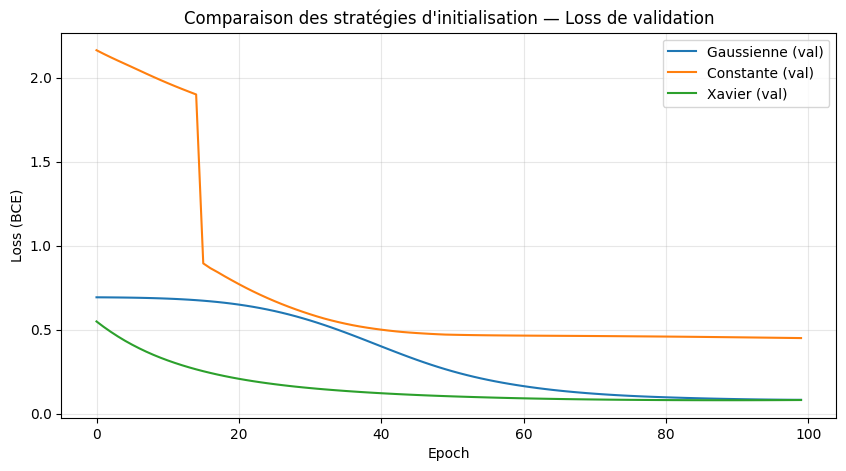

In [120]:
# --- Visualisation comparative des 3 stratégies ---
plt.figure(figsize=(10, 5))
for nom_strategie, historique in resultats_init.items():
    plt.plot(historique["val_loss"], label=f"{nom_strategie} (val)")

plt.xlabel("Epoch")
plt.ylabel("Loss (BCE)")
plt.title("Comparaison des stratégies d'initialisation — Loss de validation")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [121]:
def appliquer_init_xavier_sequential(model):
    for module in model:
        if isinstance(module, nn.Linear):
            nn.init.xavier_uniform_(module.weight)
            nn.init.constant_(module.bias, 0)

# --- Modèle Sequential ---
mlp_sequential = build_mlp_sequential(input_dim).to(device)
appliquer_init_xavier_sequential(mlp_sequential)

print("Entraînement du modèle Sequential...")
historique_sequential = entrainer_modele(
    mlp_sequential,
    X_train_tensor, y_train_tensor,
    X_val_tensor, y_val_tensor,
    epochs=100, lr=0.001, verbose=True
)

Entraînement du modèle Sequential...
Epoch [20/100] train_loss=0.3065 | val_loss=0.2940
Epoch [40/100] train_loss=0.1501 | val_loss=0.1552
Epoch [60/100] train_loss=0.0927 | val_loss=0.1058
Epoch [80/100] train_loss=0.0692 | val_loss=0.0873
Epoch [100/100] train_loss=0.0556 | val_loss=0.0788


In [122]:
# --- Modèle Custom ---
mlp_custom = MLP_Custom(input_dim).to(device)
mlp_custom.apply(init_xavier)

print("Entraînement du modèle Custom...")
historique_custom = entrainer_modele(
    mlp_custom,
    X_train_tensor, y_train_tensor,
    X_val_tensor, y_val_tensor,
    epochs=100, lr=0.001, verbose=True
)

Entraînement du modèle Custom...
Epoch [20/100] train_loss=0.2547 | val_loss=0.2637
Epoch [40/100] train_loss=0.1190 | val_loss=0.1257
Epoch [60/100] train_loss=0.0798 | val_loss=0.0908
Epoch [80/100] train_loss=0.0630 | val_loss=0.0904
Epoch [100/100] train_loss=0.0517 | val_loss=0.1033


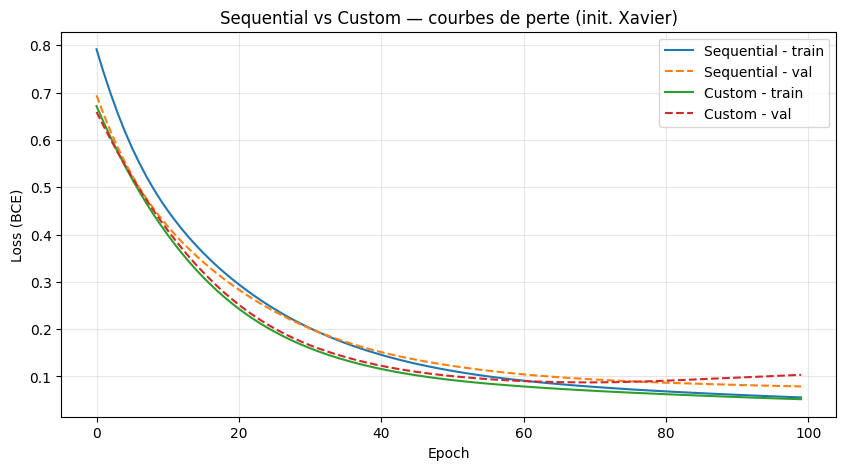

In [123]:
# --- Comparaison des courbes de loss : Sequential vs Custom ---
plt.figure(figsize=(10, 5))
plt.plot(historique_sequential["train_loss"], label="Sequential - train")
plt.plot(historique_sequential["val_loss"], label="Sequential - val", linestyle="--")
plt.plot(historique_custom["train_loss"], label="Custom - train")
plt.plot(historique_custom["val_loss"], label="Custom - val", linestyle="--")

plt.xlabel("Epoch")
plt.ylabel("Loss (BCE)")
plt.title("Sequential vs Custom — courbes de perte (init. Xavier)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [124]:
print("Modèle (custom) :", next(mlp_custom.parameters()).device)
print("Modèle (sequential) :", next(mlp_sequential.parameters()).device)
print("X_train_tensor :", X_train_tensor.device)
print("y_train_tensor :", y_train_tensor.device)
assert next(mlp_custom.parameters()).device == X_train_tensor.device, "Incohérence device !"
print("\nCohérence device vérifiée avec succès.")

Modèle (custom) : cuda:0
Modèle (sequential) : cuda:0
X_train_tensor : cuda:0
y_train_tensor : cuda:0

Cohérence device vérifiée avec succès.


In [125]:
torch.save(mlp_custom.state_dict(), "meilleur_modele_mlp.pth")
print("Modèle sauvegardé sous 'meilleur_modele_mlp.pth'")

modele_charge = MLP_Custom(input_dim)
modele_charge.load_state_dict(torch.load("meilleur_modele_mlp.pth"))
modele_charge = modele_charge.to(device)
modele_charge.eval()

print("Modèle rechargé et placé sur :", next(modele_charge.parameters()).device)

Modèle sauvegardé sous 'meilleur_modele_mlp.pth'
Modèle rechargé et placé sur : cuda:0


Accuracy  : 0.9884
Precision : 1.0000
Recall    : 0.9688
F1 Score  : 0.9841


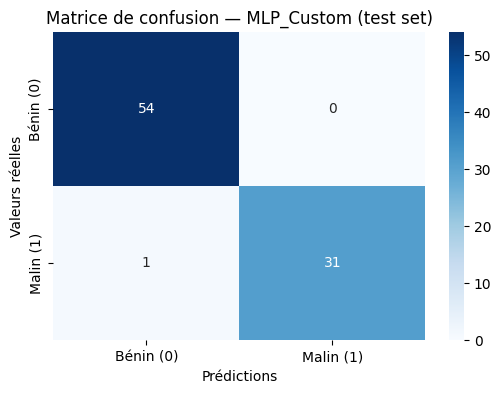

In [127]:
modele_charge.eval()

with torch.no_grad():
    predictions_test = modele_charge(X_test_tensor)
    predictions_classes = (predictions_test >= 0.5).float()

y_vrai = y_test_tensor.cpu().numpy()
y_pred = predictions_classes.cpu().numpy()

acc = accuracy_score(y_vrai, y_pred)
prec = precision_score(y_vrai, y_pred)
rec = recall_score(y_vrai, y_pred)
f1 = f1_score(y_vrai, y_pred)

print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1 Score  : {f1:.4f}")

matrice_conf = confusion_matrix(y_vrai, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(matrice_conf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Bénin (0)', 'Malin (1)'],
            yticklabels=['Bénin (0)', 'Malin (1)'])
plt.xlabel("Prédictions")
plt.ylabel("Valeurs réelles")
plt.title("Matrice de confusion — MLP_Custom (test set)")
plt.show()

Question de synthèse– Partie I :
Dans quelle mesure un MLP bien paramétré constitue-t-il une solution pertinente pour la classification tabulaire sur un dataset réel, et quelles sont ses principales limites au regard de la structure statistique des données étudiées?

La réponse : Sur le dataset Breast Cancer Wisconsin Dataset, le modèle MLP (Multi-Layer-Perceptron, c'est-à-dire un réseau de neurones) atteint une accuracy d'environ 97-98% même avec une architecture assez simple (2 couches cachées). Ce bon résultat s'explique par plusieurs facteurs :

1. Des données faciles à distinguer : Les 30 variables numériques (rayon, texture, périmètre, aire, etc) permettent de bien différencier les tumeurs bénignes des tumeurs malignes. Les frontières entre les deux classes sont donc relativement claires pour le modèle.
2. Une bonne normalisation des données : L'utilisation de StandardScaler permet de mettre toutes les variables à la même échelle. Cette étape est très importante pour un MLP, car elle facilite la convergence pendant l'apprentissage avec la descente de gradient.
3. L'initialisation Xavier : La technique Xavier Initialization aide à maintenir des activations stables entre les couches du réseau. Elle évite deux problèmes fréquents :
Le VANISHING GRADIENT : lorsque le gradient devient trop petit et ralentit l'apprentissage.
L'EXPLODING GRADIENT : lorsque le gradient devient trop grand et rend l'entraînement instable.

Pour résumer, la combinaison de données bien structurées, d'un prétraitement efficace et d'une bonne initialisation permet au MLP d'obtenir d'excellentes performances sans avoir besoin d'une architecture complexe.
Cependant, le MLP présente aussi certaines limites lorsqu'il est utilisé sur des données tabulaires :
Difficultés à capturer certaines interactions complexes : Un MLP peu profond (avec peu de couches) peut avoir du mal à apprendre des relations non linéaires très complexes entre les variables.
Sensibilité aux valeurs aberrantes (outliers) : Contrairement aux modèles basés sur les arbres comme Random Forest ou XGBoost, le MLP peut être influencé par des valeurs extrêmes, surtout si les données ne sont pas correctement normalisées.
Petits datasets : Sur des jeux de données contenant peu d'exemples, des méthodes comme les SVM (Support Vector Machine) ou les forêts aléatoires donnent souvent de meilleurs résultats. Le MLP, lui, fonctionne généralement mieux avec davantage de données.
